CV ASSIGNMENT-Lecture 2-CNN

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

#Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [5]:

#Load and preprocess data

num_classes = 10
input_shape = (28, 28, 1)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# Train and val split
val_frac = 0.1
n_val = int(len(x_train) * val_frac)
x_val, y_val = x_train[:n_val], y_train[:n_val]
x_train2, y_train2 = x_train[n_val:], y_train[n_val:]

print("Train:", x_train2.shape, "Val:", x_val.shape, "Test:", x_test.shape)

Train: (54000, 28, 28, 1) Val: (6000, 28, 28, 1) Test: (10000, 28, 28, 1)


In [6]:
2) Data augmentation layer
data_augmentation = keras.Sequential(
    [
        layers.RandomTranslation(0.1, 0.1),  # shift up to 10%
        layers.RandomRotation(0.08),         # small rotations
        layers.RandomZoom(0.1),              # zoom in/out
    ],
    name="data_augmentation",
)









In [7]:
#Building improved CNN model from the base one

#L2 weight decay
wd = 1e-4

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        data_augmentation,

        layers.Conv2D(32, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(wd), use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(64, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(wd), use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(wd), use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),

        layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(wd)),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax"),
    ],
    name="cnn_aug_bn_dropout_l2",
)

model.summary()

Model: "cnn_aug_bn_dropout_l2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 110,698 (432.41 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [9]:
# Train with callbacks

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),
]

history = model.fit(
    x_train2, y_train2,
    batch_size=128,
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.4134 - loss: 1.6642 - val_accuracy: 0.1090 - val_loss: 6.0573 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8318 - loss: 0.5773 - val_accuracy: 0.9583 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8893 - loss: 0.3992 - val_accuracy: 0.9627 - val_loss: 0.1606 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9136 - loss: 0.3257 - val_accuracy: 0.9487 - val_loss: 0.2028 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9253 - loss: 0.2881
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9253 - loss: 0.2881 - val_accuracy: 0.9497 - val_loss: 0.2033 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9371 - loss: 0

In [10]:
# Evaluate

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)

print("\nFinal metrics:")
print(f"Val accuracy:  {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Final metrics:
Val accuracy:  0.9802
Test accuracy: 0.9805


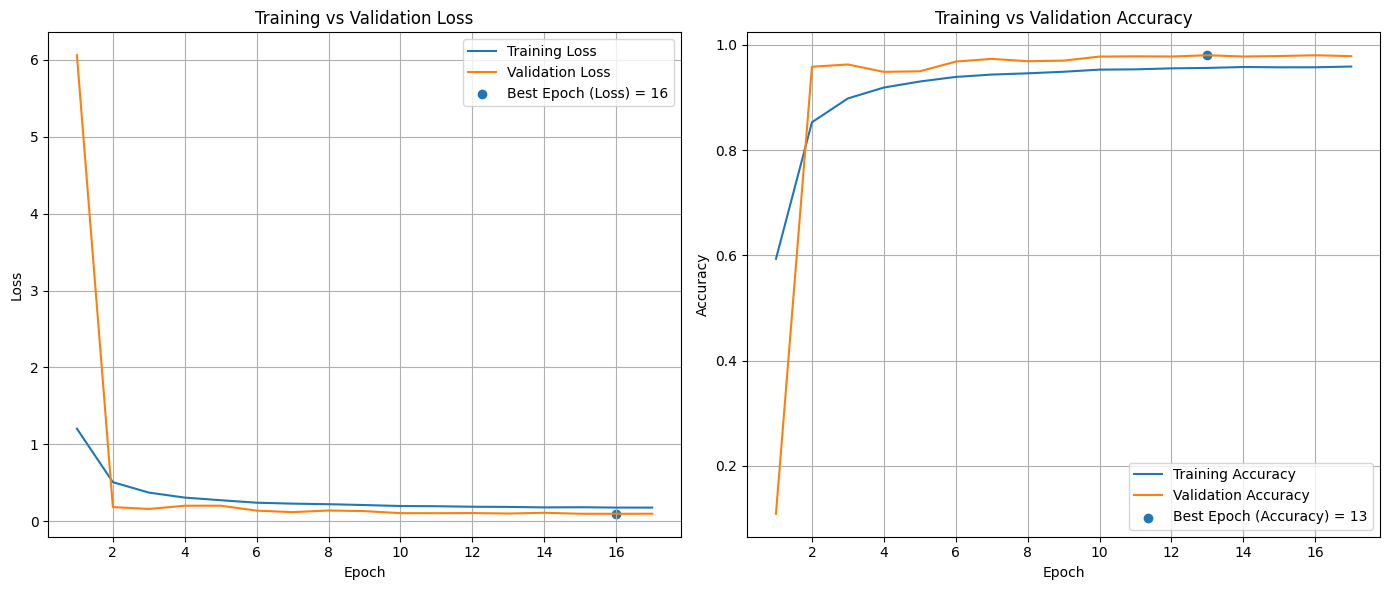

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Extract history data
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# Best epochs
best_epoch_accuracy = np.argmax(val_accuracy) + 1
best_epoch_loss = np.argmin(val_loss) + 1

plt.figure(figsize=(14, 6))

# Plot 1: Loss

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.scatter(best_epoch_loss, val_loss[best_epoch_loss - 1],
            label=f'Best Epoch (Loss) = {best_epoch_loss}')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')

plt.scatter(best_epoch_accuracy, val_accuracy[best_epoch_accuracy - 1],
            label=f'Best Epoch (Accuracy) = {best_epoch_accuracy}')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()